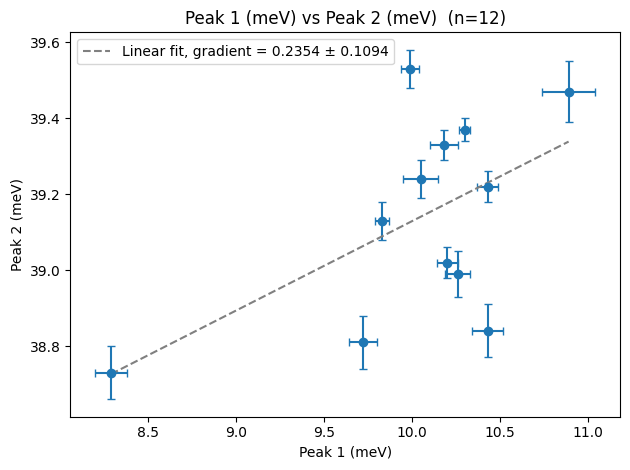

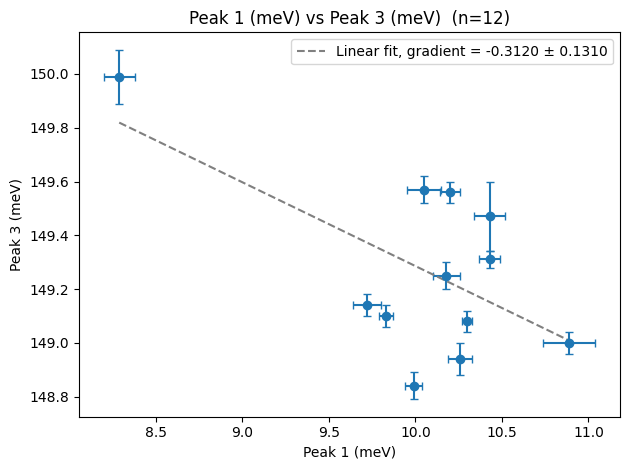

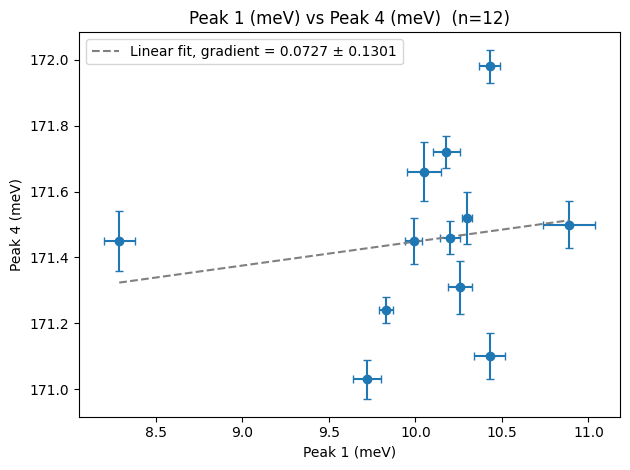

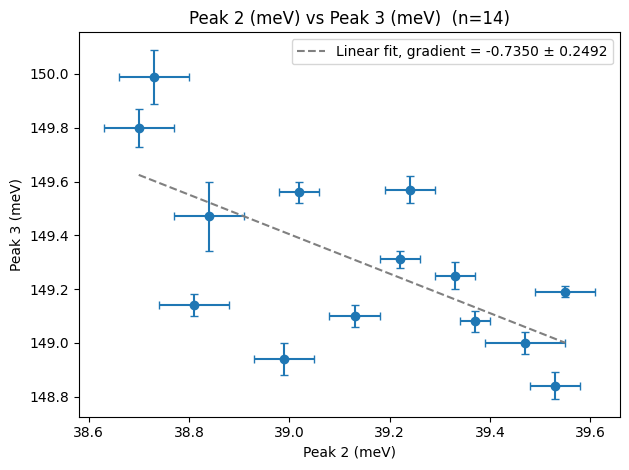

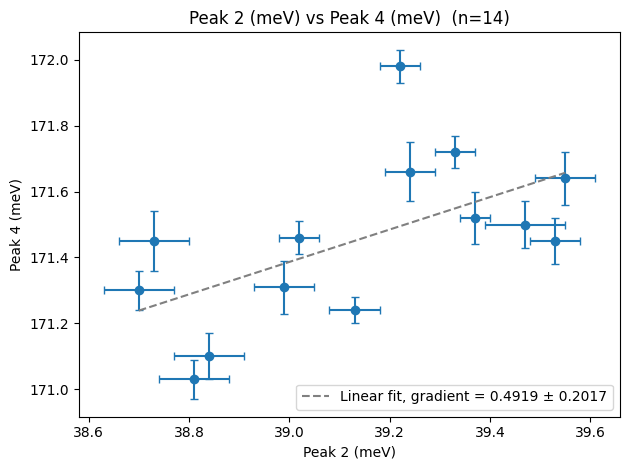

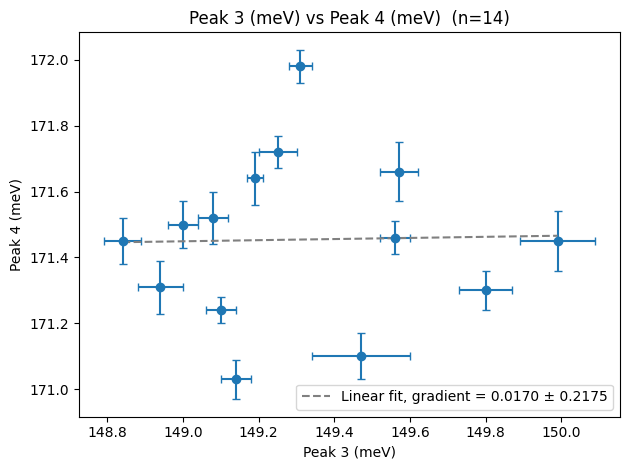

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import numpy as np

# Load data
file_path = r"C:\Users\ech77\OneDrive - University of Cambridge\Data Jan 2026\Automated PL study on Sample 7\PSB peaks strain analysis.csv"

df = pd.read_csv(file_path)
peaks = [
    ("Peak 1 (meV)", "Err 1"),
    ("Peak 2 (meV)", "Err 2"),
    ("Peak 3 (meV)", "Err 3"),
    ("Peak 4 (meV)", "Err 4"),
]

for (peak_x, err_x), (peak_y, err_y) in itertools.combinations(peaks, 2):

    # Drop rows only where THIS pair is missing
    sub = df[[peak_x, err_x, peak_y, err_y]].dropna()

    if len(sub) < 2:
        continue  # skip if not enough data points

    plt.figure()

    plt.errorbar(
        sub[peak_x],
        sub[peak_y],
        xerr=sub[err_x],
        yerr=sub[err_y],
        fmt='o',
        capsize=3
    )
    # Linear fit
    slope, intercept = np.polyfit(sub[peak_x], sub[peak_y], 1)
    # To get error in slope and intercept
    popt, pcov = np.polyfit(sub[peak_x], sub[peak_y], 1, cov=True)
    slope_err = np.sqrt(pcov[0,0])
    intercept_err = np.sqrt(pcov[1,1])

    # Plot fit line
    x_fit = np.linspace(sub[peak_x].min(), sub[peak_x].max(), 100)
    y_fit = slope * x_fit + intercept
    plt.plot(x_fit, y_fit, color='gray', linestyle='--', label=f'Linear fit, gradient = {slope:.4f} ± {slope_err:.4f}')
    plt.legend()
    plt.xlabel(peak_x)
    plt.ylabel(peak_y)
    plt.title(f"{peak_x} vs {peak_y}  (n={len(sub)})")
    plt.tight_layout()
    plt.show()
